# UASD 

## Initialization

Zorg ervoor dat je alle packages hebt gedownload, de meeste kan je downloaden via de volgende command:

`pip install torch torchaudio scikit-learn`

zorg er ook voor dat je de unilm/beats repo cloned voor het BEATs model. Clonen kan via https://github.com/microsoft/unilm/tree/master/beats. Zorg ook dat je `BEATs_iter3_plus_AS2M.pt` hebt download via de README in de unilm/beats repo.

zorg ervoor dat je je data op de juiste manier opslaat, volg hiervoor de volgende directory structure:

```text
data/
└── dcase2025t2/
    ├── dev_data/
    │   ├── processed/
    │   └── raw/
    │       └── {machine}/
    │           ├── test/
    │           ├── train/
    │           └── attributes_00.csv
    └── eval_data/
        ├── processed/
        └── raw/
            └── {machine}/
```

Hetzelfde geldt voor het opslaan van de features:

```text
features/
└── EAT/
    └── dcase2025t2_features/
        └── dev_features/
            └── raw_features/
                └── {machine}_features/
                    ├── train_features/    
                    ├── test_features/      
                    └── pca/                
                        ├── train_features_pca.npy
                        ├── test_features_pca.npy
                        └── pca_model.pkl
└── BEATs/
    └── dcase2025t2_features/
        └── dev_features/
            └── raw_features/
                └── {machine}_features/
                    ├── train_features/    
                    ├── test_features/      
                    └── pca/                
                        ├── train_features_pca.npy
                        ├── test_features_pca.npy
                        └── pca_model.pkl
```


In [1]:
import os
import sys
import torch
import torchaudio
import numpy as np
import transformers
from scipy.io import wavfile
import torch.nn as nn
from transformers import AutoModel, AutoProcessor

sys.path.insert(0, r"c:\Users\lucth\Downloads\Sorama Internship\EAT") # Adjust the path to your EAT repository

c:\Users\lucth\miniconda3\envs\sorama\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuratie en laden van EAT

In deze sectie stel je alle hoofdopties van het experiment in.
Je kiest hier of PCA en KNN aan of uit staan, of TSE wordt gebruikt, en welke fine-tune modus actief is via `FEATURE_EXTRACTOR_MODE`.

Daarna wordt het EAT-model geladen en direct geconfigureerd op basis van de gekozen modus:
- `frozen`: alle modelgewichten bevroren
- `last_layer`: alleen laatste encoderlaag trainbaar
- `lora`: parameter-efficiënte fine-tuning met LoRA
- `adapter`: alleen adapter-lagen trainbaar als die aanwezig zijn

In [14]:
# 1. hoofdcfguratie voor experimenten
MODEL_NAME = "worstchan/EAT-base_epoch30_pretrain"
USE_PCA = True  # zet pca reductie aan of uit
USE_KNN = True  # zet knn evaluatie aan of uit
USE_TSE = True  # zet tse audio enhancement aan of uit
FEATURE_EXTRACTOR_MODE = "fft"  # kies uit: frozen, last_layer, lora, adapter, fft (wang-style full fine-tune)

# extra instellingen voor tse-training
BATCH_SIZE = 32  # batchgrootte voor tse training
QUICK_SMOKE_TEST = False  # zet op true voor snelle test run
TSE_SMOKE_MAX_FILES = 128  # maximaal aantal audiofiles in smoke mode
TSE_TRAIN_EPOCHS = 10  # aantal epochs voor tse training

# interne patch-flag voor transformers compatibiliteit
_PATCH_FLAG = "_eat_compat_patched"

# 2. patch voor compatibiliteit met sommige transformers versies
# we gebruiken getattr zodat de code ook werkt als interne api ontbreekt
if not getattr(transformers.PreTrainedModel, _PATCH_FLAG, False):
    # we zoeken veilig naar de interne methode
    _orig_adjust = getattr(transformers.PreTrainedModel, "_adjust_tied_keys_with_tied_pointers", None)

    if _orig_adjust is not None:
        def _eat_adjust(self, missing_keys):
            # we zorgen dat all_tied_weights_keys altijd een dict is
            v = getattr(self, "all_tied_weights_keys", None)
            if not isinstance(v, dict):
                self.all_tied_weights_keys = {}
            return _orig_adjust(self, missing_keys)

        # patch toepassen
        transformers.PreTrainedModel._adjust_tied_keys_with_tied_pointers = _eat_adjust
        setattr(transformers.PreTrainedModel, _PATCH_FLAG, True)
        print("compatibiliteitspatch is toegepast.")
    else:
        print("patch overgeslagen: doelmethode niet gevonden in deze transformers-versie.")
else:
    print("patch was al actief.")


def set_feature_extractor_mode(model, mode):
    """stel in welke gewichten trainbaar zijn voor fine-tuning."""
    mode = str(mode).lower()

    if mode == "frozen":
        # we bevriezen alle gewichten
        for param in model.parameters():
            param.requires_grad = False
        return model

    if mode == "last_layer":
        # eerst alles bevriezen
        for param in model.parameters():
            param.requires_grad = False

        # dan proberen we de laatste encoderlaag trainbaar te maken
        layer_groups = [
            getattr(getattr(model, "encoder", None), "layers", None),
            getattr(getattr(getattr(model, "model", None), "encoder", None), "layers", None),
            getattr(model, "blocks", None),
        ]
        layer_groups = [g for g in layer_groups if g is not None and len(g) > 0]

        if layer_groups:
            for param in layer_groups[0][-1].parameters():
                param.requires_grad = True
            return model

        print("waarschuwing: laatste laag niet gevonden, fallback naar frozen.")
        return model

    if mode == "lora":
        # we proberen lora alleen toe te passen als peft beschikbaar is
        try:
            from peft import LoraConfig, get_peft_model
        except ImportError:
            print("waarschuwing: peft niet gevonden, fallback naar frozen.")
            for param in model.parameters():
                param.requires_grad = False
            return model

        # we zoeken mogelijke attention projecties voor lora
        target_modules = []
        for name, module in model.named_modules():
            if not isinstance(module, nn.Linear):
                continue
            if any(k in name.lower() for k in ["q_proj", "v_proj", "query", "value"]):
                target_modules.append(name.split(".")[-1])

        # duplicaten verwijderen en voorspelbaar sorteren
        target_modules = sorted(set(target_modules))
        if not target_modules:
            target_modules = ["q_proj", "v_proj"]

        lora_config = LoraConfig(
            r=8,
            lora_alpha=16,
            target_modules=target_modules,
            lora_dropout=0.1,
            bias="none",
        )

        model = get_peft_model(model, lora_config)
        model.print_trainable_parameters()
        return model

    if mode == "adapter":
        # we bevriezen alles en activeren alleen adapterlagen als die bestaan
        for param in model.parameters():
            param.requires_grad = False

        adapter_found = False
        for name, param in model.named_parameters():
            if "adapter" in name.lower():
                param.requires_grad = True
                adapter_found = True

        if not adapter_found:
            print("waarschuwing: geen adapterlagen gevonden, model blijft frozen.")
        return model

    if mode == "fft":
        # full fine-tune: alles trainbaar (wang-style)
        for param in model.parameters():
            param.requires_grad = True
        return model

    raise ValueError("FEATURE_EXTRACTOR_MODE moet een van deze opties zijn: frozen, last_layer, lora, adapter, fft")


# 3. model laden
try:
    print(f"laden van model: {MODEL_NAME}...")
    eat_model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)
    eat_model.eval()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    eat_model = eat_model.to(device)

    # trainbare parameters instellen volgens gekozen modus
    eat_model = set_feature_extractor_mode(eat_model, FEATURE_EXTRACTOR_MODE)

    print(f"model geladen op: {device}")
    print(f"feature extractor mode: {FEATURE_EXTRACTOR_MODE}")
except Exception as e:
    print(f"fout bij laden model: {e}")
    print("tip: controleer of je torchaudio en soundfile hebt geinstalleerd.")

patch was al actief.
laden van model: worstchan/EAT-base_epoch30_pretrain...


Loading weights: 100%|██████████| 150/150 [00:00<00:00, 172.07it/s, Materializing param=model.pre_norm.weight]                   


model geladen op: cuda
feature extractor mode: fft


## extra configuratie voor eat fine-tuning

> deze sectie voegt instellingen toe voor een echte fine-tuning loop op eat, zodat je modes als frozen, last_layer, lora en adapter eerlijker kunt vergelijken.

In [15]:
USE_EAT_FINETUNE = True  # zet op true om eat echt te fine-tunen
EAT_FINETUNE_EPOCHS = 3  # aantal epochs voor eat fine-tuning
EAT_FINETUNE_LR = 1e-5  # learning rate voor optimizer
EAT_FINETUNE_BATCH_SIZE = 8  # batchgrootte voor fine-tuning
EAT_FINETUNE_MAX_FILES = 2000  # limiet op aantal trainbestanden voor snelheid

## TSE voorbereiding en training

Deze nieuwe cel voegt dezelfde TSE-logica toe als in UASD_EXTRA.ipynb, maar nu binnen de EAT-notebook.
De code doet drie dingen:
1. audiobestanden inladen en voorbereiden voor denoising-training
2. een compact TSE-model trainen op noisy versus clean spectrogrammen
3. een functie `enhance_audio` beschikbaar maken die je later in de EAT-pipeline kunt aanroepen

Belangrijk: alleen als `USE_TSE = True` staat, wordt TSE echt getraind en toegepast.

Trainingdata: voor elk jaar in `TSE_TRAIN_YEARS` worden **alle** development-machines gebruikt (alle `.wav` onder `data/<jaar>/dev_data/raw/<machine>/train`), niet alleen één machine.

In [16]:
# instellingen voor tse data
# train op alle development machines: voor elk jaar in TSE_TRAIN_YEARS alle .../raw/<machine>/train/*.wav
TSE_TRAIN_YEARS = ["dcase2025t2"]  # pas aan als je meerdere jaren wilt meenemen
TSE_SEGMENT_SECONDS = 1.0
STFT_N_FFT = 512
STFT_HOP_LENGTH = 160


def _get_stft_window(waveform):
    """maak een hann-window op hetzelfde device en dtype als de waveform."""
    # dezelfde window voor stft en istft voorkomt reconstructie-waarschuwingen
    return torch.hann_window(STFT_N_FFT, device=waveform.device, dtype=waveform.dtype)


def waveform_to_spec(waveform):
    """zet waveforms om naar stft magnitude voor denoising."""
    # we gebruiken een expliciete hann-window voor consistente spectrale reconstructie
    window = _get_stft_window(waveform)
    spec = torch.stft(
        waveform,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP_LENGTH,
        window=window,
        return_complex=True,
    )
    return torch.abs(spec)


def create_noisy_sample(waveform):
    """maak een lichte ruisversie van de input voor self-supervised denoising."""
    # we kiezen elke keer een kleine willekeurige ruissterkte
    noise_level = torch.empty(1).uniform_(0.01, 0.05).item()
    noise = noise_level * torch.randn_like(waveform)
    return waveform + noise


def _load_waveform_for_tse(file_path, target_sr):
    """laad wav, maak mono en resample naar target sample rate."""
    try:
        waveform, sr = torchaudio.load(file_path)
    except RuntimeError:
        # fallback via scipy als torchaudio backend faalt
        sr, data = wavfile.read(file_path)
        data = np.asarray(data)

        if np.issubdtype(data.dtype, np.integer):
            max_val = np.iinfo(data.dtype).max
            data = data.astype(np.float32) / float(max_val)
        else:
            data = data.astype(np.float32)

        if data.ndim == 1:
            waveform = torch.from_numpy(data).unsqueeze(0)
        else:
            waveform = torch.from_numpy(data.T)

        sr = int(sr)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0)
    else:
        waveform = waveform.squeeze(0)

    if sr != target_sr:
        waveform = torchaudio.functional.resample(
            waveform.unsqueeze(0),
            sr,
            target_sr,
        ).squeeze(0)

    return waveform


class TSEWaveformDataset(torch.utils.data.Dataset):
    """dataset met vaste audiosegmenten voor tse-training."""

    def __init__(self, file_paths, target_sr, segment_seconds=1.0):
        self.file_paths = file_paths
        self.target_sr = target_sr
        self.segment_length = max(1, int(segment_seconds * target_sr))

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        waveform = _load_waveform_for_tse(file_path, self.target_sr)

        # we maken alle segmenten even lang met crop of padding
        if waveform.shape[0] >= self.segment_length:
            max_start = waveform.shape[0] - self.segment_length
            start = torch.randint(0, max_start + 1, (1,)).item() if max_start > 0 else 0
            waveform = waveform[start : start + self.segment_length]
        else:
            pad_len = self.segment_length - waveform.shape[0]
            waveform = torch.nn.functional.pad(waveform, (0, pad_len))

        return (waveform,)


class TSEModel(nn.Module):
    """licht encoder-decoder model voor magnitude denoising."""

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 8, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, 2, stride=2, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # we reconstrueren een schonere magnitude uit noisy input
        z = self.encoder(x)
        out = self.decoder(z)
        return out


def enhance_audio(waveform):
    """verbeter audio met het getrainde tse-model."""
    # als tse uit staat of model ontbreekt, geven we de originele waveform terug
    if not USE_TSE or "tse_model" not in globals():
        return waveform

    # we maken een gedeelde hann-window zodat stft en istft exact matchen
    window = _get_stft_window(waveform)

    spec = torch.stft(
        waveform,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP_LENGTH,
        window=window,
        return_complex=True,
    )

    magnitude = torch.abs(spec)
    phase = torch.angle(spec)

    # model verwacht vorm [batch, channel, freq, time]
    magnitude = magnitude.unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        enhanced_mag = tse_model(magnitude).squeeze(0).squeeze(0)

    enhanced_wave = torch.istft(
        enhanced_mag * torch.exp(1j * phase),
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP_LENGTH,
        window=window,
        length=waveform.shape[-1],
    )
    return enhanced_wave


# tse alleen opbouwen en trainen als USE_TSE aan staat
if USE_TSE:
    quick_smoke_test = bool(QUICK_SMOKE_TEST)
    smoke_max_files = int(TSE_SMOKE_MAX_FILES)
    tse_max_files = smoke_max_files if quick_smoke_test else None

    if quick_smoke_test:
        print(f"quick smoke mode aan: max {tse_max_files} bestanden voor tse.")

    from config import iter_all_data

    wav_paths = []
    for year, machine, input_folder in iter_all_data(years=TSE_TRAIN_YEARS, dataset="dev"):
        train_dir = input_folder / "train"
        if not train_dir.is_dir():
            print(f"tse: sla over (geen train-map): {year}-{machine} -> {train_dir}")
            continue
        for root, _, files in os.walk(train_dir):
            for file_name in files:
                if file_name.lower().endswith(".wav"):
                    wav_paths.append(os.path.join(root, file_name))

    wav_paths.sort()
    if tse_max_files is not None:
        wav_paths = wav_paths[:tse_max_files]

    if len(wav_paths) == 0:
        print("geen wav-bestanden gevonden voor tse. controleer data/ en TSE_TRAIN_YEARS.")
    else:
        dataset = TSEWaveformDataset(
            wav_paths,
            target_sr=16000,
            segment_seconds=TSE_SEGMENT_SECONDS,
        )
        loader = torch.utils.data.DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=False,
        )
        print(f"tse dataloader gemaakt met {len(dataset)} bestanden.")

        tse_model = TSEModel().to(device)
        optimizer = torch.optim.Adam(tse_model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        epochs = 1 if quick_smoke_test else int(TSE_TRAIN_EPOCHS)
        if quick_smoke_test:
            print("quick smoke mode aan: tse training op 1 epoch.")

        for epoch in range(epochs):
            total_loss = 0.0
            for batch in loader:
                clean_wave = batch[0].to(device)
                noisy_wave = create_noisy_sample(clean_wave)

                # we trainen denoising in het magnitude domein
                clean_spec = waveform_to_spec(clean_wave).unsqueeze(1).to(device)
                noisy_spec = waveform_to_spec(noisy_wave).unsqueeze(1).to(device)

                optimizer.zero_grad()
                pred = tse_model(noisy_spec)
                loss = loss_fn(pred, clean_spec)
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            print(f"tse epoch {epoch + 1}/{epochs} - loss: {total_loss:.4f}")
else:
    print("USE_TSE staat uit: tse training wordt overgeslagen.")

tse dataloader gemaakt met 1000 bestanden.
tse epoch 1/10 - loss: 7.6294
tse epoch 2/10 - loss: 3.8044
tse epoch 3/10 - loss: 0.9816
tse epoch 4/10 - loss: 0.2970
tse epoch 5/10 - loss: 0.1700
tse epoch 6/10 - loss: 0.1683
tse epoch 7/10 - loss: 0.1601
tse epoch 8/10 - loss: 0.1559
tse epoch 9/10 - loss: 0.1547
tse epoch 10/10 - loss: 0.1552


## Audio preprocessing voor EAT-embeddings

Deze aangepaste cel splitst de stappen op:
1. waveform laden en naar 16 kHz + mono brengen
2. optioneel TSE toepassen op de waveform
3. waveform omzetten naar mel-features voor EAT

Zo is duidelijk zichtbaar dat TSE echt vóór `wav_to_mel` wordt toegepast.

In [17]:
TARGET_LENGTH = 512   # aantal frames in de tijdas
NORM_MEAN = -4.268    # gemiddelde voor normalisatie (van EAT training)
NORM_STD = 4.569      # standaarddeviatie voor normalisatie
MIN_WAVEFORM_SAMPLES = 400  # minimale lengte om korte audioclips stabiel te verwerken


def load_waveform(wav_path, target_sr=16000):
    """laad een wav-bestand en zet het om naar mono met vaste sample rate."""
    try:
        waveform, sr = torchaudio.load(wav_path)
    except RuntimeError:
        # fallback via scipy als torchaudio backend problemen geeft
        sr, data = wavfile.read(wav_path)
        data = np.asarray(data)

        if np.issubdtype(data.dtype, np.integer):
            max_val = np.iinfo(data.dtype).max
            data = data.astype(np.float32) / float(max_val)
        else:
            data = data.astype(np.float32)

        if data.ndim == 1:
            waveform = torch.from_numpy(data).unsqueeze(0)
        else:
            waveform = torch.from_numpy(data.T)

        sr = int(sr)

    # we zetten stereo om naar mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0)
    else:
        waveform = waveform.squeeze(0)

    # we resamplen naar de sample rate die EAT verwacht
    if sr != target_sr:
        waveform = torchaudio.functional.resample(
            waveform.unsqueeze(0),
            sr,
            target_sr,
        ).squeeze(0)

    # we voorkomen te korte inputs voor latere stft/mel stappen
    if waveform.shape[0] < MIN_WAVEFORM_SAMPLES:
        pad_len = MIN_WAVEFORM_SAMPLES - waveform.shape[0]
        waveform = torch.nn.functional.pad(waveform, (0, pad_len))

    return waveform


def wav_to_mel_from_waveform(waveform, target_length=TARGET_LENGTH):
    """zet een waveform tensor om naar een mel spectrogram voor EAT."""
    # kaldi fbank verwacht een tensor met kanaaldimensie [1, tijd]
    waveform = waveform.unsqueeze(0)

    # bereken kaldi fbank met 128 mel-bins
    fbank = torchaudio.compliance.kaldi.fbank(
        waveform,
        htk_compat=True,
        sample_frequency=16000,
        use_energy=False,
        window_type='hanning',
        num_mel_bins=128,
        dither=0.0,
        frame_shift=10
    )  # vorm: [T, 128]

    # pad of trim naar vaste lengte
    T = fbank.shape[0]
    if T < target_length:
        fbank = torch.nn.functional.pad(fbank, (0, 0, 0, target_length - T))
    else:
        fbank = fbank[:target_length, :]

    # normaliseer zoals bij EAT pretraining
    fbank = (fbank - NORM_MEAN) / (NORM_STD * 2)

    # voeg batch- en kanaal-dimensie toe: [1, 1, T, 128]
    return fbank.unsqueeze(0).unsqueeze(0)


def extract_eat_embedding(wav_path):
    """geeft een 768-dimensionale embedding terug voor een wav-bestand."""
    # stap 1: laad waveform
    waveform = load_waveform(wav_path)

    # stap 2: pas optioneel tse toe op de waveform voor mel-conversie
    if USE_TSE:
        waveform = enhance_audio(waveform.to(device)).cpu()

    # stap 3: zet om naar mel en stuur naar device
    mel = wav_to_mel_from_waveform(waveform).to(device)

    with torch.no_grad():
        # de huggingface eat extract_features geeft [B, T, 768] terug
        out = eat_model.extract_features(mel)
        embedding = out[:, 0, :].squeeze(0).cpu().numpy()  # [768]

    return embedding

## eat fine-tuning loop voor eerlijke mode-vergelijking

> deze cel traint eat echt (alleen op trainbare parameters), zodat verschillen tussen frozen, last_layer, lora en adapter ook werkelijk in de embeddings terechtkomen.

## wang-style fine-tune: classificatie-head en arcface loss

in deze sectie voegen we een echte classificatie-head toe aan eat, zoals in wang 2025. we trainen deze head met een arcface loss (of cross-entropy als arcface niet beschikbaar is) op attribute- en domainlabels. dit maakt eat veel krachtiger voor supervised fine-tune, precies zoals in de winnende dcase2025 systematiek.

- de classificatie-head voorspelt attributen of domeinen van de machine (afhankelijk van de data).
- arcface loss zorgt voor betere scheiding tussen klassen dan gewone cross-entropy.
- deze aanpak wordt gebruikt in de "full fine-tune" (fft) en lora fine-tune modi.

let op: deze cellen zijn volledig geïntegreerd in de notebookstructuur, met uitleg in kleine letters en nederlandse comments.

In [18]:
# simpele classificatie-head en arcface loss voor eat fine-tune (wang-style)

# deze head wordt bovenop de eat backbone geplaatst en traint op attribute/domain labels

# arcface loss wordt gebruikt voor betere klassen-scheiding, zoals in wang 2025


import torch.nn.functional as F

class EATClassificationHead(nn.Module):
    """eenvoudige classificatie-head voor attribute/domain classificatie"""
    def __init__(self, in_dim=768, num_classes=8):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, x):
        # x: [batch, 768] -> logits: [batch, num_classes]
        return self.fc(x)

class ArcFaceLoss(nn.Module):
    """arcface loss implementatie voor supervised fine-tune"""
    def __init__(self, s=30.0, m=0.5):
        super().__init__()
        self.s = s  # schaalfactor
        self.m = m  # marge

    def forward(self, logits, labels):
        # logits: [batch, num_classes], labels: [batch]
        # softmax over aangepaste logit met marge
        one_hot = F.one_hot(labels, num_classes=logits.size(1)).float()
        theta = torch.acos(torch.clamp(logits, -1.0 + 1e-7, 1.0 - 1e-7))
        target_logits = torch.cos(theta + self.m)
        output = logits * (1 - one_hot) + target_logits * one_hot
        output = output * self.s
        loss = F.cross_entropy(output, labels)
        return loss

# fallback naar gewone cross-entropy als arcface niet werkt
try:
    arcface_loss = ArcFaceLoss()
except Exception:
    arcface_loss = nn.CrossEntropyLoss()
    print("arcface niet beschikbaar, fallback naar cross-entropy")

In [19]:
from torch.utils.data import Dataset, DataLoader  # we importeren dataset en dataloader voor batching
from config import iter_all_data  # we gebruiken dezelfde dataloop als in de rest van de notebook

# nieuwe dataset voor supervised fine-tune met labels (attribute/domain)
class EATSupervisedDataset(Dataset):
    """dataset die mel + label teruggeeft voor supervised fine-tune"""
    def __init__(self, wav_paths, label_dict):
        self.wav_paths = wav_paths
        self.label_dict = label_dict  # dict: pad -> label
    def __len__(self):
        return len(self.wav_paths)
    def __getitem__(self, idx):
        wav_path = str(self.wav_paths[idx])
        waveform = load_waveform(wav_path, target_sr=16000)
        if USE_TSE:
            waveform = enhance_audio(waveform.to(device)).cpu()
        mel = wav_to_mel_from_waveform(waveform)
        label = self.label_dict.get(wav_path, 0)  # default naar 0 als label ontbreekt
        return mel.squeeze(0), label

# bestaande one-class fine-tune blijft beschikbaar voor frozen/last_layer/unsupervised
class EATTrainWaveDataset(Dataset):  # we maken een datasetklasse voor train-wave bestanden
    def __init__(self, wav_paths):  # we initialiseren met een lijst van paden
        self.wav_paths = wav_paths  # we bewaren alle wav-paden

    def __len__(self):  # we geven de lengte van de dataset terug
        return len(self.wav_paths)  # we retourneren het aantal bestanden

    def __getitem__(self, idx):  # we laden een item op index
        wav_path = str(self.wav_paths[idx])  # we zetten pad om naar string
        waveform = load_waveform(wav_path, target_sr=16000)  # we laden de waveform op 16 khz
        if USE_TSE:  # we passen optioneel tse toe voor consistente preprocessing
            waveform = enhance_audio(waveform.to(device)).cpu()  # we draaien tse op device en brengen terug naar cpu
        mel = wav_to_mel_from_waveform(waveform)  # we zetten waveform om naar eat-mel
        return mel.squeeze(0), wav_path  # we geven [1, t, 128] en pad terug

if not USE_EAT_FINETUNE:  # we stoppen als fine-tuning uit staat
    print("use_eat_finetune staat uit: eat fine-tuning wordt overgeslagen.")  # we geven duidelijke status
else:  # we starten de fine-tuning flow
    trainable_params = [p for p in eat_model.parameters() if p.requires_grad]  # we pakken alleen trainbare gewichten
    if len(trainable_params) == 0:  # we checken of er wel iets trainbaar is
        print("geen trainbare eat-parameters gevonden voor deze mode; fine-tuning wordt overgeslagen.")  # we melden waarom er niets gebeurt
    else:  # we gaan door als er trainbare parameters zijn
        all_train_wavs = []  # we maken een lijst voor alle trainbestanden
        label_dict = {}  # pad -> label voor supervised
        for year, machine, input_folder in iter_all_data():  # we lopen door alle machines en jaren
            train_input = input_folder / "train"  # we pakken de trainmap
            if train_input.exists():  # we checken of de trainmap bestaat
                wavs = sorted(list(train_input.glob("**/*.wav")))
                all_train_wavs.extend(wavs)
                # labels uit bestandsnaam (voor demo, in praktijk uit csv/metadata)
                for wav in wavs:
                    if "anomaly" in wav.name.lower():
                        label_dict[str(wav)] = 1
                    else:
                        label_dict[str(wav)] = 0

        if len(all_train_wavs) == 0:  # we stoppen als er geen data is
            print("geen train wav-bestanden gevonden voor eat fine-tuning.")  # we melden dat data ontbreekt
        else:  # we hebben data en gaan trainen
            max_files = int(EAT_FINETUNE_MAX_FILES)  # we lezen de limiet op aantal files
            if max_files > 0 and len(all_train_wavs) > max_files:  # we beperken de dataset voor snelheid
                all_train_wavs = all_train_wavs[:max_files]  # we houden alleen de eerste max_files

            # kies fine-tune mode: supervised (wang-style) of one-class (default)
            if FEATURE_EXTRACTOR_MODE in ["fft", "lora"]:
                # wang-style supervised fine-tune met classificatie-head
                num_classes = 2  # pas aan voor attribute/domain
                head = EATClassificationHead(in_dim=768, num_classes=num_classes).to(device)
                params = list(eat_model.parameters()) + list(head.parameters())
                optimizer = torch.optim.Adam(params, lr=float(EAT_FINETUNE_LR))
                train_dataset = EATSupervisedDataset(all_train_wavs, label_dict)
                train_loader = DataLoader(train_dataset, batch_size=int(EAT_FINETUNE_BATCH_SIZE), shuffle=True, drop_last=False)
                eat_model.train()
                head.train()
                for epoch in range(int(EAT_FINETUNE_EPOCHS)):
                    epoch_loss = 0.0
                    epoch_steps = 0
                    for mel_batch, label_batch in train_loader:
                        mel_batch = mel_batch.to(device)
                        label_batch = label_batch.to(device)
                        optimizer.zero_grad()
                        out = eat_model.extract_features(mel_batch)
                        emb = out[:, 0, :]
                        logits = head(emb)
                        loss = arcface_loss(logits, label_batch)
                        loss.backward()
                        optimizer.step()
                        epoch_loss += float(loss.item())
                        epoch_steps += 1
                    avg_loss = epoch_loss / max(epoch_steps, 1)
                    print(f"eat fft/lora epoch {epoch + 1}/{int(EAT_FINETUNE_EPOCHS)} - loss: {avg_loss:.6f}")
                eat_model.eval()
                head.eval()
                print("eat fft/lora fine-tuning afgerond; je kunt nu features extraheren voor eerlijke modevergelijking.")
            else:
                # bestaande one-class fine-tune voor frozen/last_layer/unsupervised
                train_dataset = EATTrainWaveDataset(all_train_wavs)
                train_loader = DataLoader(train_dataset, batch_size=int(EAT_FINETUNE_BATCH_SIZE), shuffle=True, drop_last=False)
                optimizer = torch.optim.Adam(trainable_params, lr=float(EAT_FINETUNE_LR))
                eat_model.train()
                for epoch in range(int(EAT_FINETUNE_EPOCHS)):
                    epoch_loss = 0.0
                    epoch_steps = 0
                    for mel_batch, _ in train_loader:
                        mel_batch = mel_batch.to(device)
                        optimizer.zero_grad()
                        out = eat_model.extract_features(mel_batch)
                        emb = out[:, 0, :]
                        center = emb.detach().mean(dim=0, keepdim=True)
                        loss = ((emb - center) ** 2).mean()
                        loss.backward()
                        optimizer.step()
                        epoch_loss += float(loss.item())
                        epoch_steps += 1
                    avg_loss = epoch_loss / max(epoch_steps, 1)
                    print(f"eat one-class epoch {epoch + 1}/{int(EAT_FINETUNE_EPOCHS)} - loss: {avg_loss:.6f}")
                eat_model.eval()
                print("eat one-class fine-tuning afgerond; je kunt nu features extraheren voor eerlijke modevergelijking.")

eat fft/lora epoch 1/3 - loss: 0.270627
eat fft/lora epoch 2/3 - loss: 0.000000
eat fft/lora epoch 3/3 - loss: 0.000000
eat fft/lora fine-tuning afgerond; je kunt nu features extraheren voor eerlijke modevergelijking.


## Extracting Features (6 min per machine)

In [20]:
from config import iter_all_data, get_features_path, get_train_features_path, get_test_features_path

model_used = f"EAT_{FEATURE_EXTRACTOR_MODE}_tse{int(USE_TSE)}"

# Process all machines across all years
for year, machine, input_folder in iter_all_data():
    output_folder = get_features_path(model_used, year, machine, dataset="dev")
    print(f"\n Processing {year} - {machine}")
    print(f"Input:  {input_folder}")
    print(f"Output: {output_folder}")

    # ========== TRAIN FEATURES ==========
    train_input = input_folder / "train"
    if train_input.exists():
        train_output = get_train_features_path(model_used, year, machine, dataset="dev")
        
        # Check if train extraction is already done (>=1000 files)
        existing_train = list(train_output.rglob("*.npy"))
        if len(existing_train) >= 1000:
            print(f"Skipping train - {len(existing_train)} train features already present")
        else:
            # Count files first
            train_wav_files = list(train_input.glob("**/*.wav"))
            if not train_wav_files:
                print(f"No train .wav files found")
            else:
                print(f"Processing train: Found {len(train_wav_files)} audio files")

                # Process each file
                train_processed = 0
                for wav_file in train_wav_files:
                    try:
                        # Load and process audio
                        embedding = extract_eat_embedding(str(wav_file))
                        # Create output path (mirror input structure)
                        relative_path = wav_file.relative_to(train_input)
                        out_file = train_output / relative_path.with_suffix('.npy')
                        out_file.parent.mkdir(parents=True, exist_ok=True)

                        # Save embedding
                        np.save(out_file, embedding)
                        train_processed += 1

                    except Exception as e:
                        print(f"Error processing {wav_file}: {e}")

                print(f"Processed {train_processed}/{len(train_wav_files)} train files")
    else:
        print(f"No train folder found")

    # ========== TEST FEATURES ==========
    test_input = input_folder / "test"
    if test_input.exists():
        test_output = get_test_features_path(model_used, year, machine, dataset="dev")
        
        # Check if test extraction is already done (>=200 files)
        existing_test = list(test_output.rglob("*.npy"))
        if len(existing_test) >= 200:
            print(f"Skipping test - {len(existing_test)} test features already present")
        else:
            # Count files first
            test_wav_files = list(test_input.glob("**/*.wav"))
            if not test_wav_files:
                print(f"No test .wav files found")
            else:
                print(f"Processing test: Found {len(test_wav_files)} audio files")

                # Process each file
                test_processed = 0
                for wav_file in test_wav_files:
                    try:
                        # Load and process audio
                        embedding = extract_eat_embedding(str(wav_file))

                        # Create output path (mirror input structure)
                        relative_path = wav_file.relative_to(test_input)
                        out_file = test_output / relative_path.with_suffix('.npy')
                        out_file.parent.mkdir(parents=True, exist_ok=True)

                        # Save embedding
                        np.save(out_file, embedding)
                        test_processed += 1

                    except Exception as e:
                        print(f"Error processing {wav_file}: {e}")

                print(f"Processed {test_processed}/{len(test_wav_files)} test files")
    else:
        print(f"No test folder found")

print("\n All feature extraction completed")


 Processing dcase2025t2 - ToyCar
Input:  c:\Users\lucth\Downloads\Sorama Internship\Victor_New\data\dcase2025t2\dev_data\raw\ToyCar
Output: c:\Users\lucth\Downloads\Sorama Internship\Victor_New\features\EAT_fft_tse1\dcase2025t2_features\dev_features\raw_features\ToyCar_features
Skipping train - 1000 train features already present
Skipping test - 200 test features already present

 Processing dcase2025t2 - ToyTrain
Input:  c:\Users\lucth\Downloads\Sorama Internship\Victor_New\data\dcase2025t2\dev_data\raw\ToyTrain
Output: c:\Users\lucth\Downloads\Sorama Internship\Victor_New\features\EAT_fft_tse1\dcase2025t2_features\dev_features\raw_features\ToyTrain_features
Skipping train - 1000 train features already present
Skipping test - 200 test features already present

 Processing dcase2025t2 - bearing
Input:  c:\Users\lucth\Downloads\Sorama Internship\Victor_New\data\dcase2025t2\dev_data\raw\bearing
Output: c:\Users\lucth\Downloads\Sorama Internship\Victor_New\features\EAT_fft_tse1\dcase2025

## PCA (optioneel via USE_PCA)

Deze cel voert alleen PCA uit als `USE_PCA = True` staat in de configuratie.
Als `USE_PCA = False`, dan wordt PCA expliciet overgeslagen en blijft de workflow op ruwe embeddings werken.

Let op: als er al een `pca_model.pkl` bestaat, wordt die machine overgeslagen. Verwijder in dat geval de map `pca/` voor die machine als je opnieuw wilt fitten op complete features.

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from config import iter_all_data, get_features_path, get_train_features_path, get_test_features_path, get_pca_path
import pickle
import os

# deze helper blijft beschikbaar, ook als USE_PCA uit staat
def apply_pca_to_machine(year, machine, features_path):
    """apply pca op features van een specifieke machine en sla resultaten op."""
    pca_dir = get_pca_path(model_used, year, machine, dataset="dev")
    flag_file = pca_dir / "pca_model.pkl"

    if flag_file.exists():
        print(f"Skipping {year}-{machine}: PCA results already exist.")
        return None, "exists"

    train_features_path = get_train_features_path(model_used, year, machine, dataset="dev")
    if not train_features_path.exists():
        print(f"No train features found for {year}-{machine}")
        return None, None

    train_files = list(train_features_path.glob("**/*.npy"))
    if not train_files:
        print(f"No train feature files found for {year}-{machine}")
        return None, None

    print(f"Processing {len(train_files)} train features for {year}-{machine}")

    train_embeddings = []
    for file in train_files:
        try:
            emb = np.load(file)
            train_embeddings.append(emb)
        except Exception as e:
            print(f"Error loading train {file}: {e}")

    if not train_embeddings:
        print(f"No valid train embeddings for {year}-{machine}")
        return None, None

    X_train = np.vstack(train_embeddings)
    print(f"   Train shape: {X_train.shape}")

    pca_reduced = PCA(n_components=0.95)
    X_train_pca = pca_reduced.fit_transform(X_train)
    print(f"   Train PCA shape: {X_train_pca.shape} (components: {pca_reduced.n_components_})")

    test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
    X_test_pca = None
    if test_features_path.exists():
        test_files = list(test_features_path.glob("**/*.npy"))
        if test_files:
            test_embeddings = []
            for file in test_files:
                try:
                    emb = np.load(file)
                    test_embeddings.append(emb)
                except Exception as e:
                    print(f"Error loading test {file}: {e}")

            if test_embeddings:
                X_test = np.vstack(test_embeddings)
                X_test_pca = pca_reduced.transform(X_test)
                print(f"   Test PCA shape: {X_test_pca.shape}")

    np.save(pca_dir / "train_features_pca.npy", X_train_pca)
    if X_test_pca is not None:
        np.save(pca_dir / "test_features_pca.npy", X_test_pca)

    with open(pca_dir / "pca_model.pkl", 'wb') as f:
        pickle.dump(pca_reduced, f)

    variance_info = {
        'explained_variance_ratio': pca_reduced.explained_variance_ratio_,
        'cumulative_variance': np.cumsum(pca_reduced.explained_variance_ratio_),
        'n_components': pca_reduced.n_components_,
        'train_original_shape': X_train.shape,
        'train_reduced_shape': X_train_pca.shape,
        'test_reduced_shape': X_test_pca.shape if X_test_pca is not None else None
    }
    np.save(pca_dir / "variance_info.npy", variance_info)

    return X_train_pca, pca_reduced

if not USE_PCA:
    # we slaan pca bewust over als de schakelaar uit staat
    print("USE_PCA staat uit: deze PCA-cel wordt overgeslagen.")
else:
    print("Starting PCA processing for all machines...\n")
    pca_results = {}

    for year, machine, _ in iter_all_data():
        features_path = get_features_path(model_used, year, machine, dataset="dev")

        if not features_path.exists():
            print(f"Features directory not found: {features_path}")
            continue

        print(f"\n Processing {year} - {machine}")
        X_pca, pca_model = apply_pca_to_machine(year, machine, features_path)

        if X_pca is not None:
            pca_results[f"{year}_{machine}"] = {
                'features': X_pca,
                'model': pca_model,
                'path': features_path
            }

    print(f"\n PCA completed for {len(pca_results)} machines")
    print("PCA results saved in each machine's features/pca/ directory")

Starting PCA processing for all machines...


 Processing dcase2025t2 - ToyCar
Skipping dcase2025t2-ToyCar: PCA results already exist.

 Processing dcase2025t2 - ToyTrain
Skipping dcase2025t2-ToyTrain: PCA results already exist.

 Processing dcase2025t2 - bearing
Skipping dcase2025t2-bearing: PCA results already exist.

 Processing dcase2025t2 - fan
Skipping dcase2025t2-fan: PCA results already exist.

 Processing dcase2025t2 - gearbox
Skipping dcase2025t2-gearbox: PCA results already exist.

 Processing dcase2025t2 - slider
Skipping dcase2025t2-slider: PCA results already exist.

 Processing dcase2025t2 - valve
Skipping dcase2025t2-valve: PCA results already exist.

 PCA completed for 0 machines
PCA results saved in each machine's features/pca/ directory


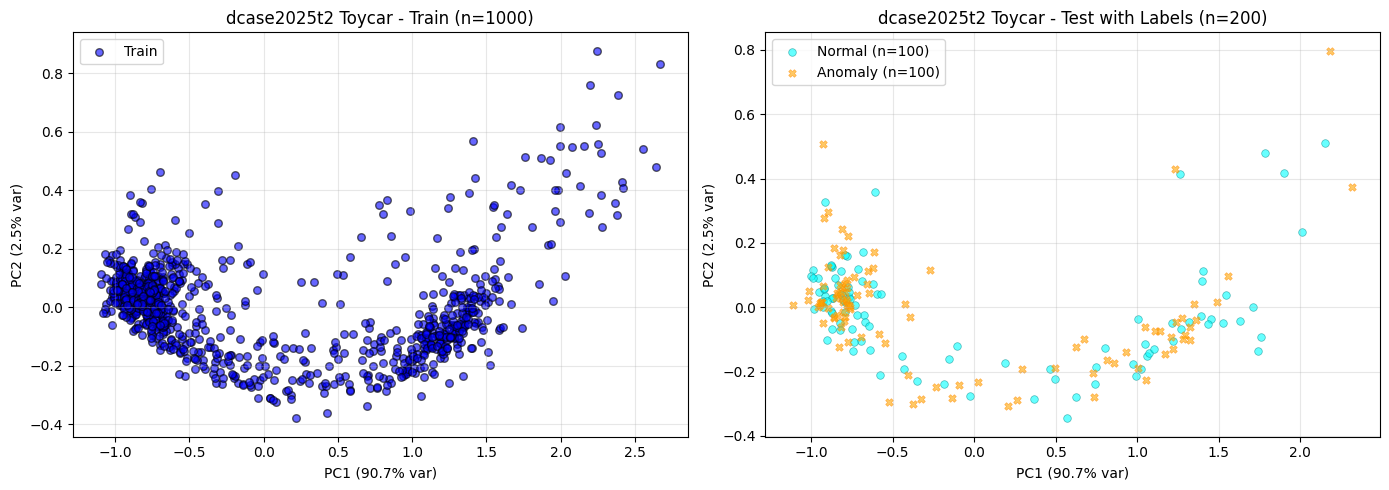

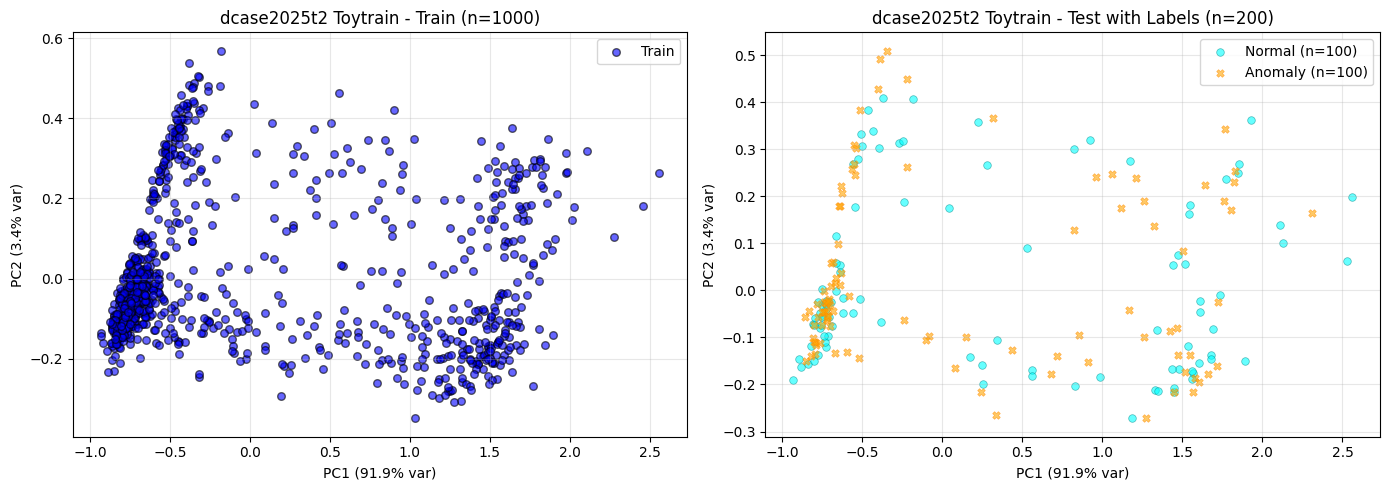

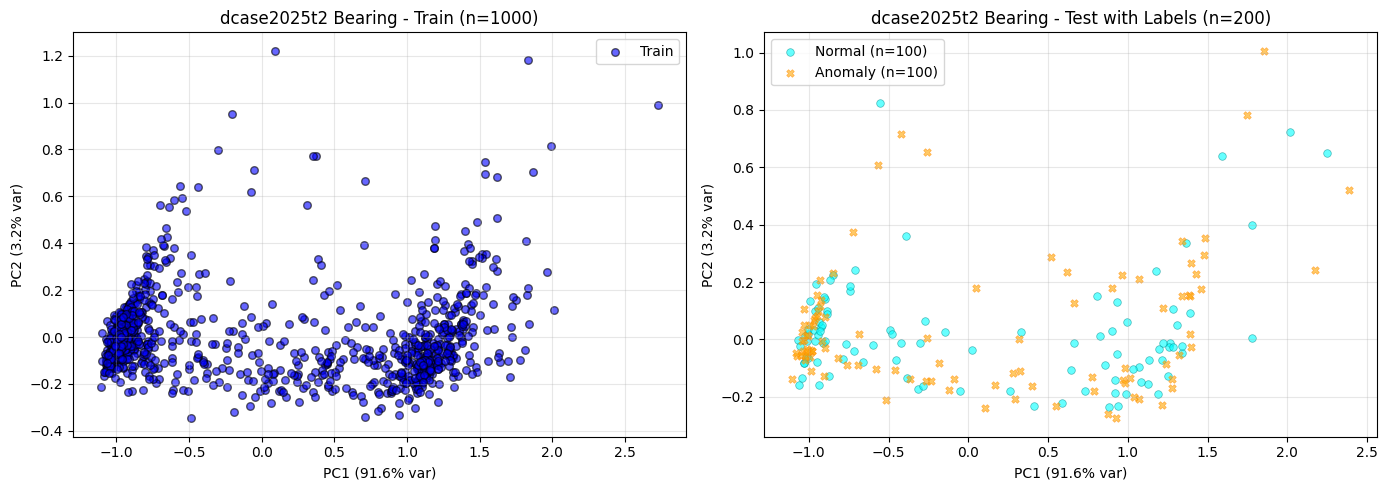

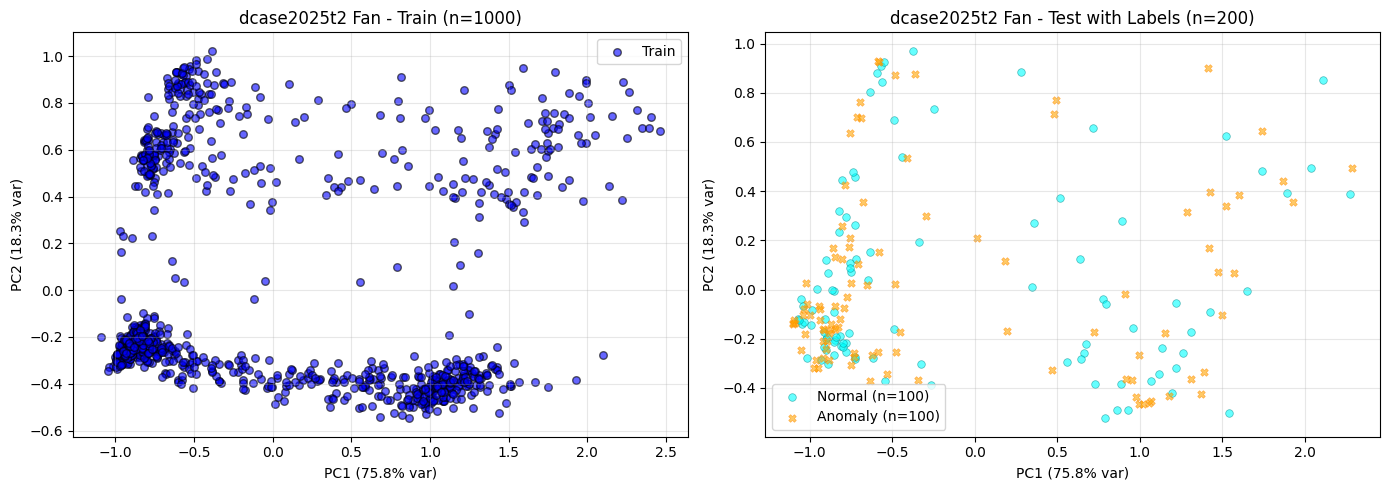

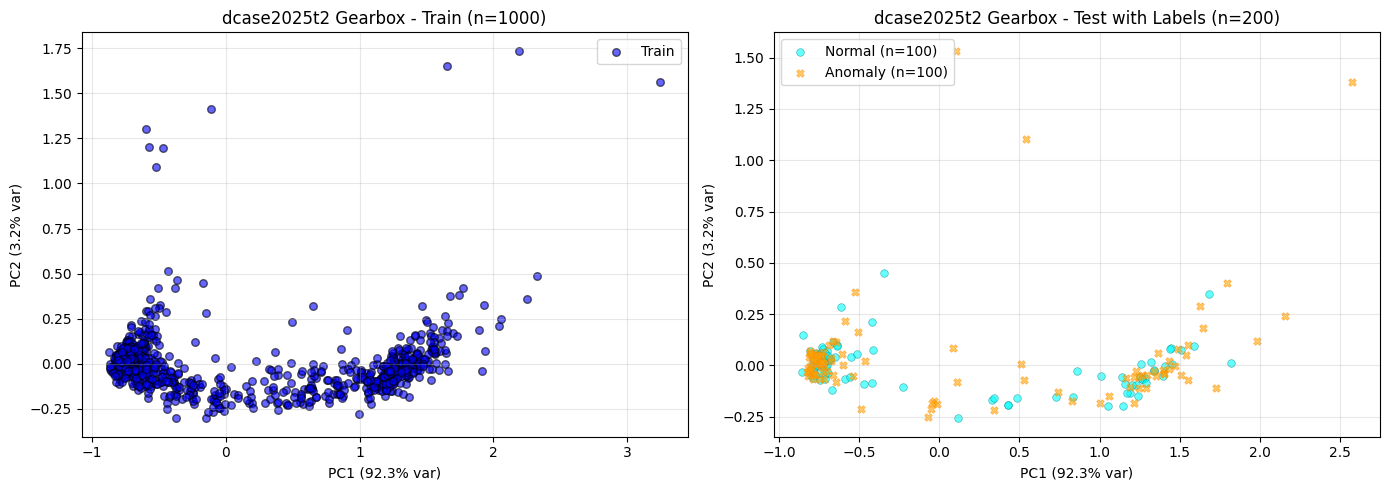

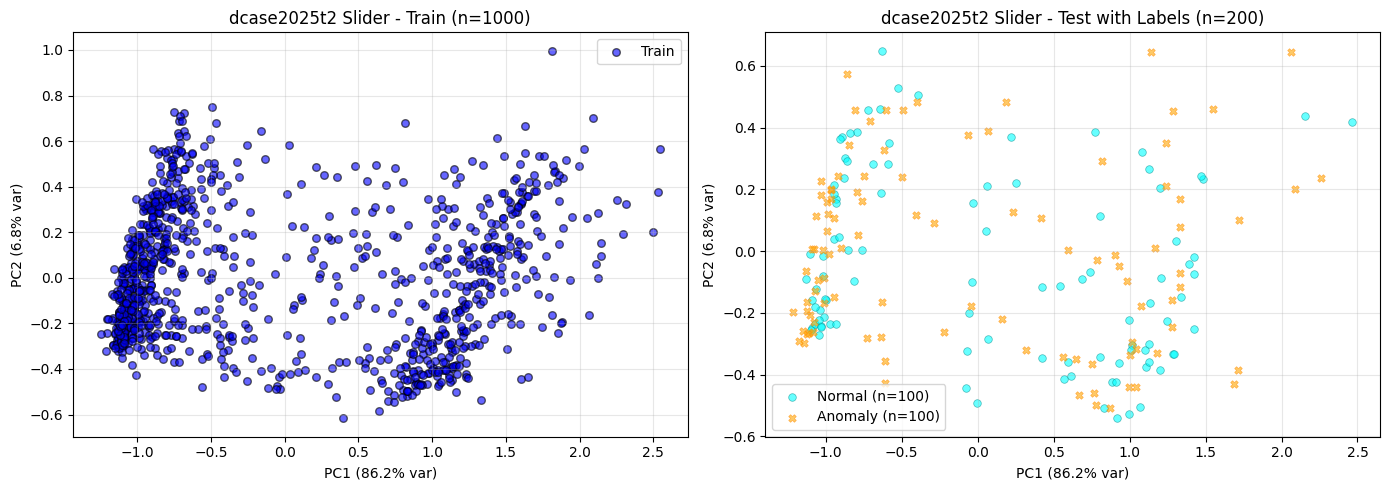

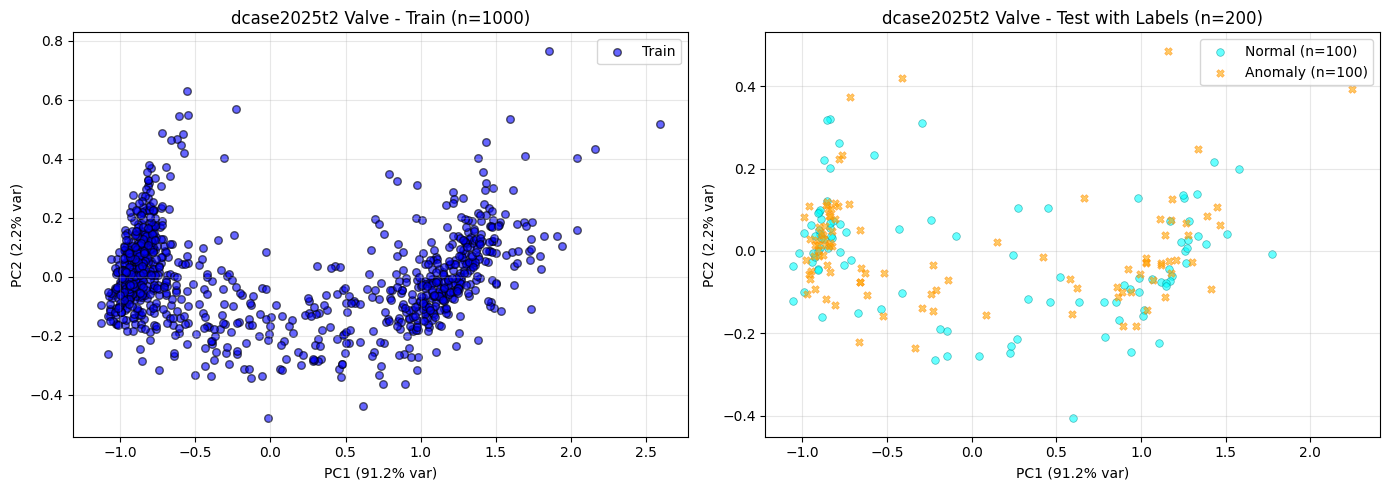

In [22]:
# generate individuele pca-plots per machine (train en test)
import matplotlib.pyplot as plt
from config import iter_all_data, load_pca_results, get_test_features_path

def extract_label_from_filename(filename):
    """extract 'normal' of 'anomaly' label uit bestandsnaam."""
    filename_lower = str(filename).lower()
    if 'anomaly' in filename_lower:
        return 1  # anomaly
    elif 'normal' in filename_lower:
        return 0  # normal
    else:
        return None  # onbekend

if not USE_PCA:
    # zonder pca-resultaten heeft deze visualisatie geen invoer
    print("USE_PCA staat uit: pca-visualisatie wordt overgeslagen.")
else:
    for year, machine, _ in iter_all_data():
        X_train, variance_info_train = load_pca_results(model_used, year, machine, split="train")
        X_test, variance_info_test = load_pca_results(model_used, year, machine, split="test")

        if X_train is None and X_test is None:
            continue

        fig, axs = plt.subplots(1, 2, figsize=(14, 5))

        if X_train is not None:
            axs[0].scatter(X_train[:, 0], X_train[:, 1], alpha=0.6, s=30, color='blue', edgecolors='k', label='Train')
            axs[0].set_xlabel(f'PC1 ({variance_info_train["explained_variance_ratio"][0]:.1%} var)')
            axs[0].set_ylabel(f'PC2 ({variance_info_train["explained_variance_ratio"][1]:.1%} var)')
            axs[0].set_title(f'{year} {machine.title()} - Train (n={X_train.shape[0]})')
            axs[0].grid(True, alpha=0.3)
            axs[0].legend()
        else:
            axs[0].text(0.5, 0.5, 'No train data', ha='center', va='center')
            axs[0].set_title(f'{year} {machine.title()} - Train')

        if X_test is not None:
            test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
            test_files = sorted(list(test_features_path.glob("**/*.npy")))

            test_labels = []
            for file in test_files:
                label = extract_label_from_filename(file.name)
                if label is not None:
                    test_labels.append(label)

            if len(test_labels) == X_test.shape[0]:
                test_labels = np.array(test_labels)
                normal_mask = test_labels == 0
                anomaly_mask = test_labels == 1

                if np.sum(normal_mask) > 0:
                    axs[1].scatter(
                        X_test[normal_mask, 0],
                        X_test[normal_mask, 1],
                        alpha=0.6,
                        s=30,
                        color='cyan',
                        edgecolors='darkcyan',
                        linewidth=0.5,
                        label=f'Normal (n={np.sum(normal_mask)})',
                    )
                if np.sum(anomaly_mask) > 0:
                    axs[1].scatter(
                        X_test[anomaly_mask, 0],
                        X_test[anomaly_mask, 1],
                        alpha=0.6,
                        s=30,
                        color='orange',
                        edgecolors='darkorange',
                        linewidth=0.5,
                        marker='X',
                        label=f'Anomaly (n={np.sum(anomaly_mask)})',
                    )
            else:
                axs[1].scatter(X_test[:, 0], X_test[:, 1], alpha=0.6, s=30, color='red', edgecolors='k', label='Test')

            axs[1].set_xlabel(f'PC1 ({variance_info_test["explained_variance_ratio"][0]:.1%} var)')
            axs[1].set_ylabel(f'PC2 ({variance_info_test["explained_variance_ratio"][1]:.1%} var)')
            axs[1].set_title(f'{year} {machine.title()} - Test with Labels (n={X_test.shape[0]})')
            axs[1].grid(True, alpha=0.3)
            axs[1].legend()
        else:
            axs[1].text(0.5, 0.5, 'No test data', ha='center', va='center')
            axs[1].set_title(f'{year} {machine.title()} - Test')

        plt.tight_layout()
        plt.show()

## KNN evaluatie (optioneel via USE_KNN)

Deze cel draait KNN-anomaliedetectie alleen als `USE_KNN = True` staat.
De code ondersteunt nu beide scenario's:
- met PCA (`USE_PCA = True`): KNN op PCA-features
- zonder PCA (`USE_PCA = False`): KNN direct op ruwe embeddings

Zo kun je combinaties als PCA aan/uit en KNN aan/uit netjes vergelijken binnen dezelfde notebook.

In [23]:
from sklearn.neighbors import NearestNeighbors
from config import get_pca_path, get_train_features_path, get_test_features_path, load_pca_results, iter_all_data

class KNNAnomalyDetector:
    """
    knn-gebaseerde anomaliedetectie met afstand tot de k-de buur.
    """

    def __init__(self, k=5, threshold_percentile=95):
        self.k = k
        self.threshold_percentile = threshold_percentile
        self.knn = None
        self.threshold = None
        self.training_distances = None

    def fit(self, X_train):
        # we fitten knn op train-data (normale data)
        self.knn = NearestNeighbors(n_neighbors=self.k + 1)
        self.knn.fit(X_train)

        distances, _ = self.knn.kneighbors(X_train)
        self.training_distances = distances[:, self.k]
        self.threshold = np.percentile(self.training_distances, self.threshold_percentile)

    def predict(self, X_test):
        if self.knn is None:
            raise ValueError("Detector must be fitted first using .fit()")

        distances, _ = self.knn.kneighbors(X_test)
        test_distances = distances[:, self.k]

        # boven de drempel classificeren we als anomalie
        predictions = (test_distances > self.threshold).astype(int)
        return predictions, test_distances

    def predict_single(self, x):
        predictions, distances = self.predict(x.reshape(1, -1))
        return predictions[0], distances[0]


def extract_label_from_filename(filename):
    """haal 'normal' of 'anomaly' uit de bestandsnaam."""
    filename_lower = str(filename).lower()
    if 'anomaly' in filename_lower:
        return 1
    if 'normal' in filename_lower:
        return 0
    return None


def load_raw_split_with_labels(year, machine, split):
    """laad ruwe features (zonder pca) en labels op basis van bestandsnamen."""
    if split == "train":
        split_path = get_train_features_path(model_used, year, machine, dataset="dev")
    else:
        split_path = get_test_features_path(model_used, year, machine, dataset="dev")

    if not split_path.exists():
        return None, None

    files = sorted(list(split_path.glob("**/*.npy")))
    if not files:
        return None, None

    features = []
    labels = []

    for file in files:
        try:
            feat = np.load(file)
            features.append(feat)
        except Exception as e:
            print(f"Error loading {file}: {e}")
            continue

        label = extract_label_from_filename(file.name)
        labels.append(label)

    if not features:
        return None, None

    X = np.vstack(features)

    # voor train mag label ontbreken, voor test houden we alleen geldige labels over
    if split == "test":
        valid_idx = [i for i, lbl in enumerate(labels) if lbl is not None]
        if not valid_idx:
            return None, None
        X = X[valid_idx]
        y = np.array([labels[i] for i in valid_idx])
        return X, y

    return X, None


def load_eval_data(year, machine):
    """laad train/test data voor knn met of zonder pca afhankelijk van USE_PCA."""
    if USE_PCA:
        # pca-modus: train en test uit opgeslagen pca-resultaten
        X_train, _ = load_pca_results(model_used, year, machine, split="train")
        X_test, _ = load_pca_results(model_used, year, machine, split="test")
        if X_train is None or X_test is None:
            return None, None, None

        test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
        test_files = sorted(list(test_features_path.glob("**/*.npy")))
        labels = [extract_label_from_filename(file.name) for file in test_files]
        valid_idx = [i for i, lbl in enumerate(labels) if lbl is not None]
        if not valid_idx:
            return None, None, None

        if len(valid_idx) != X_test.shape[0]:
            # bij mismatch stoppen we om verkeerde evaluatie te voorkomen
            print(f"Waarschuwing: label/aantal mismatch bij {year}-{machine}, machine wordt overgeslagen.")
            return None, None, None

        y_test = np.array([labels[i] for i in valid_idx])
        return X_train, X_test, y_test

    # geen pca: direct op ruwe embeddings
    X_train, _ = load_raw_split_with_labels(year, machine, split="train")
    X_test, y_test = load_raw_split_with_labels(year, machine, split="test")
    if X_train is None or X_test is None or y_test is None:
        return None, None, None
    return X_train, X_test, y_test


if not USE_KNN:
    # knn bewust overslaan wanneer de schakelaar uit staat
    print("USE_KNN staat uit: KNN-evaluatie wordt overgeslagen.")
else:
    from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score

    results_summary = []

    for year, machine, _ in iter_all_data():
        X_train, X_test, y_test = load_eval_data(year, machine)
        if X_train is None:
            continue

        detector = KNNAnomalyDetector(k=5, threshold_percentile=95)
        detector.fit(X_train)
        predictions, distances = detector.predict(X_test)

        tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, predictions, average='binary')

        # we zetten afstanden om naar score voor auc-berekening
        denom = distances.max() if distances.max() > 0 else 1.0
        y_scores = 1 - (distances / denom)
        roc_auc = roc_auc_score(y_test, y_scores)

        results_summary.append({
            'machine': f"{year}-{machine}",
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'tp': tp,
            'tn': tn,
            'fp': fp,
            'fn': fn,
            'test_samples': X_test.shape[0]
        })

    if results_summary:
        print(f"\n\n{'=' * 100}")
        print("SUMMARY: Performance Across All Machines")
        print(f"{'=' * 100}")
        print(f"{'Machine':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'ROC-AUC':<12} {'Samples':<10}")
        print(f"{'-' * 100}")

        for result in results_summary:
            print(
                f"{result['machine']:<20} {result['precision']:<12.4f} {result['recall']:<12.4f} "
                f"{result['f1']:<12.4f} {result['roc_auc']:<12.4f} {result['test_samples']:<10}"
            )

        print(f"{'-' * 100}")
        avg_precision = np.mean([r['precision'] for r in results_summary])
        avg_recall = np.mean([r['recall'] for r in results_summary])
        avg_f1 = np.mean([r['f1'] for r in results_summary])
        avg_auc = np.mean([r['roc_auc'] for r in results_summary])
        print(f"{'Average':<20} {avg_precision:<12.4f} {avg_recall:<12.4f} {avg_f1:<12.4f} {avg_auc:<12.4f}")
        print(f"{'=' * 100}")
    else:
        print("Geen resultaten: controleer of features en labels beschikbaar zijn.")



SUMMARY: Performance Across All Machines
Machine              Precision    Recall       F1-Score     ROC-AUC      Samples   
----------------------------------------------------------------------------------------------------
dcase2025t2-ToyCar   0.8000       0.0400       0.0762       0.5292       200       
dcase2025t2-ToyTrain 0.3684       0.0700       0.1176       0.5343       200       
dcase2025t2-bearing  0.6111       0.1100       0.1864       0.4646       200       
dcase2025t2-fan      0.5000       0.2500       0.3333       0.5031       200       
dcase2025t2-gearbox  0.6500       0.1300       0.2167       0.4574       200       
dcase2025t2-slider   0.7333       0.1100       0.1913       0.4833       200       
dcase2025t2-valve    0.4545       0.0500       0.0901       0.5588       200       
----------------------------------------------------------------------------------------------------
Average              0.5882       0.1086       0.1731       0.5044      


## extra evaluatie: cosine knn (k=1) en ensemble van checkpoints

in deze cel voegen we een extra evaluatie toe met cosine distance knn (k=1), zoals in wang 2025. daarnaast laten we zien hoe je eenvoudig een ensemble van meerdere checkpoints kunt maken door anomaly scores te middelen.

- cosine distance knn (k=1) geeft een eerlijkere vergelijking met wang.
- ensemble van checkpoints verhoogt de robuustheid van de eindscore.

alles is uitgelegd in kleine letters en met nederlandse comments.

In [24]:
# cosine distance knn (k=1) evaluatie en ensemble van checkpoints (wang-style)

from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import roc_auc_score
import numpy as np

# helper voor cosine knn (k=1)
def cosine_knn_anomaly_score(X_train, X_test):
    # bereken cosine afstand van elke test sample tot alle train samples
    dists = cosine_distances(X_test, X_train)  # shape: [n_test, n_train]
    min_dists = dists.min(axis=1)  # neem minimale afstand per test sample
    return min_dists

# voorbeeld: evaluatie per machine
for year, machine, _ in iter_all_data():
    X_train, X_test, y_test = load_eval_data(year, machine)
    if X_train is None or X_test is None or y_test is None:
        continue
    # cosine knn anomaly score
    min_dists = cosine_knn_anomaly_score(X_train, X_test)
    # score normaliseren (1 - afstand)
    y_scores = 1 - (min_dists / (min_dists.max() if min_dists.max() > 0 else 1.0))
    auc = roc_auc_score(y_test, y_scores)
    print(f"cosine knn (k=1) {year}-{machine}: auc={auc:.4f}")

# ensemble van checkpoints (voorbeeld: middelen van 3 anomaly score arrays)
def ensemble_scores(*score_arrays):
    # neem gemiddelde van meerdere anomaly score arrays
    return np.mean(np.stack(score_arrays, axis=0), axis=0)

# voorbeeld gebruik:
# y_scores1 = ... # anomaly scores van checkpoint 1
# y_scores2 = ... # anomaly scores van checkpoint 2
# y_scores3 = ... # anomaly scores van checkpoint 3
# y_scores_ensemble = ensemble_scores(y_scores1, y_scores2, y_scores3)
# auc_ensemble = roc_auc_score(y_test, y_scores_ensemble)
# print(f"ensemble auc: {auc_ensemble:.4f}")

cosine knn (k=1) dcase2025t2-ToyCar: auc=0.5063
cosine knn (k=1) dcase2025t2-ToyTrain: auc=0.5108
cosine knn (k=1) dcase2025t2-bearing: auc=0.5090
cosine knn (k=1) dcase2025t2-fan: auc=0.5096
cosine knn (k=1) dcase2025t2-gearbox: auc=0.4558
cosine knn (k=1) dcase2025t2-slider: auc=0.5044
cosine knn (k=1) dcase2025t2-valve: auc=0.5486
